# End-to-End SVM Loan Classification Project

## Import Libraries

In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

# Data Handling
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import ( StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder)
# SVM
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score)

# Save Model
import joblib


## Load Dataset

In [4]:
df=pd.read_csv('loan_approved.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## EDA

In [ ]:
sns.countplot(x='Loan_Status',data=df); plt.show()

In [6]:
df.info()
df.describe(include='all')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    object 
 1   Gender                  601 non-null    object 
 2   Married                 611 non-null    object 
 3   Dependents              599 non-null    object 
 4   Education               614 non-null    object 
 5   Self_Employed           582 non-null    object 
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              592 non-null    float64
 9   Loan_Amount_Term        600 non-null    float64
 10  Credit_History          564 non-null    float64
 11  Property_Area           614 non-null    object 
 12  Loan_Status (Approved)  614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


Loan_ID                    0
Gender                    13
Married                    3
Dependents                15
Education                  0
Self_Employed             32
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                22
Loan_Amount_Term          14
Credit_History            50
Property_Area              0
Loan_Status (Approved)     0
dtype: int64

In [8]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing

,Missing Values,Percentage
Loan_ID,0,0.000000
Gender,13,2.117264
Married,3,0.488599
Dependents,15,2.442997
Education,0,0.000000
Self_Employed,32,5.211726
ApplicantIncome,0,0.000000
CoapplicantIncome,0,0.000000
LoanAmount,22,3.583062
Loan_Amount_Term,14,2.280130


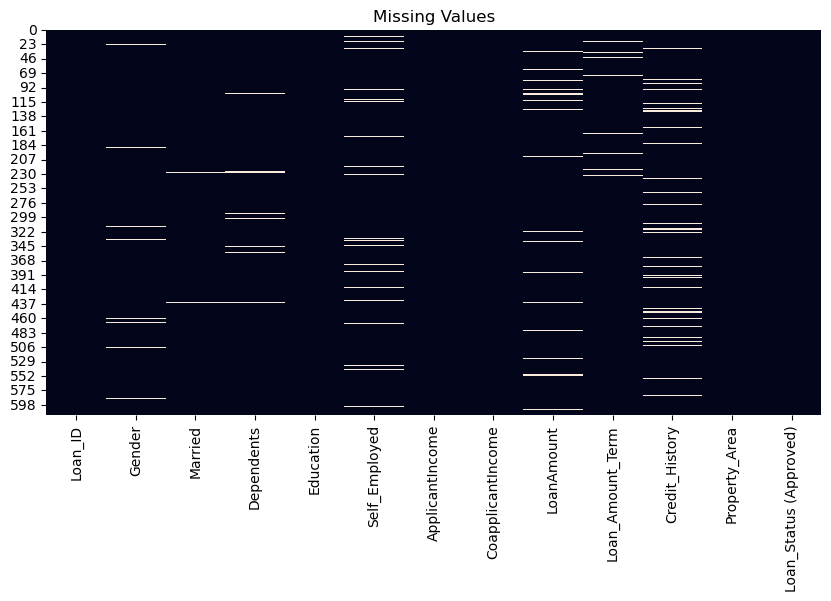

In [10]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")

plt.show()

In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

In [ ]:
df = df.drop_duplicates()

In [12]:
# ==========================================
# Numerical and Categorical Columns
# ==========================================

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical Columns")
print(numerical_cols)

print("\nCategorical Columns")
print(categorical_cols)

In [ ]:
# ==========================================
# Target Variable Distribution
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Loan_Status (Approved)',
    palette='Set2'
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

In [ ]:
df["Loan_Status (Approved)"].value_counts(normalize=True)*100

In [ ]:
# ==========================================
# Histograms
# ==========================================

df[numerical_cols].hist(
    figsize=(14,8),
    bins=20,
    edgecolor="black"
)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# Boxplots
# ==========================================

plt.figure(figsize=(15,10))

for i, column in enumerate(numerical_cols):

    plt.subplot(2,3,i+1)

    sns.boxplot(y=df[column])

    plt.title(column)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# Countplots
# ==========================================

categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

plt.figure(figsize=(15,12))

for i, column in enumerate(categorical_features):

    plt.subplot(3,2,i+1)

    sns.countplot(
        data=df,
        x=column,
        palette="Set3"
    )

    plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Gender",
    hue="Loan_Status (Approved)"
)

plt.title("Loan Status by Gender")

plt.show()

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Education",
    hue="Loan_Status (Approved)"
)

plt.title("Loan Status by Education")

plt.show()

In [ ]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="Property_Area",
    hue="Loan_Status (Approved)"
)

plt.title("Loan Status by Property Area")

plt.show()

In [ ]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# ==========================================
# Pairplot
# ==========================================

selected_features = [
    "ApplicantIncome",
    "LoanAmount",
    "Credit_History",
    "Loan_Status (Approved)"
]

sns.pairplot(
    df[selected_features],
    hue="Loan_Status (Approved)"
)

plt.show()

In [ ]:
# ==========================================
# Drop Loan_ID
# ==========================================

df.drop("Loan_ID", axis=1, inplace=True)

df.head()

In [14]:
# ==========================================
# Features and Target
# ==========================================

X = df.drop("Loan_Status (Approved)", axis=1)

y = df["Loan_Status (Approved)"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

In [ ]:
# ==========================================
# Encode Target Variable
# ==========================================

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(label_encoder.classes_)

In [ ]:
# ==========================================
# Feature Types
# ==========================================

ordinal_features = [
    "Dependents"
]

nominal_features = [
    "Gender",
    "Married",
    "Education",
    "Self_Employed",
    "Property_Area"
]

numerical_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

print("Ordinal Features")
print(ordinal_features)

print("\nNominal Features")
print(nominal_features)

print("\nNumerical Features")
print(numerical_features)

In [16]:
categorical_cols = X.select_dtypes(include="object").columns

numerical_cols = X.select_dtypes(exclude="object").columns

In [20]:
# ==========================================
# Numerical Pipeline
# ==========================================

numerical_pipeline = Pipeline([
    
    ("imputer", SimpleImputer(strategy="median")),
    
    ("scaler", StandardScaler())
])

In [22]:
# ==========================================
# Ordinal Pipeline
# ==========================================

ordinal_pipeline = Pipeline([
    
    ("imputer", SimpleImputer(strategy="most_frequent")),
    
    ("encoder",
     OrdinalEncoder(
         categories=[
             ["0","1","2","3+"]
         ]
     ))
])

In [ ]:
# ==========================================
# Nominal Pipeline
# ==========================================

nominal_pipeline = Pipeline([
    
    ("imputer",
     SimpleImputer(strategy="most_frequent")),
    
    ("encoder",
     OneHotEncoder(handle_unknown="ignore"))
])

## Preprocessing

In [24]:
# ==========================================
# Column Transformer
# ==========================================

preprocessor = ColumnTransformer(
    
    transformers=[
        
        ("num",
         numerical_pipeline,
         numerical_features),
        
        ("ord",
         ordinal_pipeline,
         ordinal_features),
        
        ("nom",
         nominal_pipeline,
         nominal_features)
        
    ]
)

## Train/Test

In [27]:
# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size=0.20,
    
    random_state=42,
    
    stratify=y
)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

In [29]:
# ==========================================
# Fit Preprocessor
# ==========================================

preprocessor.fit(X_train)

['preprocessor.pkl']

In [ ]:
# ==========================================
# Save Transformer
# ==========================================

joblib.dump(
    preprocessor,
    "loan_preprocessor.pkl"
)

## Save Transformer

In [38]:
# ==========================================
# Transform Data
# ==========================================

X_train_processed = preprocessor.transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [40]:
print("Original Training Shape")

print(X_train.shape)

print()

print("Processed Training Shape")

print(X_train_processed.shape)

(491, 20)
(123, 20)


## Model

In [42]:
# ==========================================
# Build SVM Classifier
# ==========================================

svm_model = SVC(
    
    kernel="rbf",
    
    C=1,
    
    gamma="scale",
    
    random_state=42
)

svm_model.fit(
    
    X_train_processed,
    
    y_train
)

print("Model Training Completed Successfully!")

SVC(C=1, random_state=42)

In [44]:
# ==========================================
# Predict Test Data
# ==========================================

y_pred = svm_model.predict(X_test_processed)

print(y_pred[:20])

In [ ]:
predictions = label_encoder.inverse_transform(y_pred)

predictions[:20]

In [46]:
accuracy = accuracy_score(
    
    y_test,
    
    y_pred
)

print(f"Accuracy : {accuracy:.4f}")

print(f"Accuracy : {accuracy*100:.2f}%")

Accuracy : 0.8536585365853658


In [48]:
cm = confusion_matrix(
    
    y_test,
    
    y_pred
)

cm

[[21 17]
 [ 1 84]]


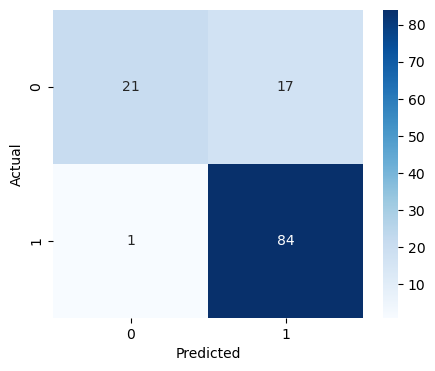

In [50]:
plt.figure(figsize=(6,5))

sns.heatmap(
    
    cm,
    
    annot=True,
    
    cmap="Blues",
    
    fmt="d"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [52]:
print(

classification_report(

    y_test,

    y_pred

)

)

              precision    recall  f1-score   support

           N       0.95      0.55      0.70        38
           Y       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [ ]:
y_prob = svm_model.decision_function(
    
    X_test_processed
)

In [ ]:
fpr, tpr, thresholds = roc_curve(
    
    y_test,
    
    y_prob
)

auc_score = roc_auc_score(
    
    y_test,
    
    y_prob
)

In [ ]:
plt.figure(figsize=(6,5))

plt.plot(
    
    fpr,
    
    tpr,
    
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    
    [0,1],
    
    [0,1],
    
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [54]:
joblib.dump(svm, "loan_svm.pkl")

['loan_svm.pkl']

In [ ]:
# Grid Search CV 

In [34]:
params={'C':[0.1,1,10],'gamma':['scale',0.1,0.01],'kernel':['linear','rbf']}
grid=GridSearchCV(SVC(),params,cv=5)
grid.fit(X_train_t,y_train)
best=grid.best_estimator_

## Evaluation

In [ ]:
pred=best.predict(X_test_t)
print(accuracy_score(y_test,pred))
print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

## Save Model

In [ ]:
joblib.dump(best,'svm_model.pkl')

## Predict New

In [ ]:
prep=joblib.load('preprocessor.pkl')
model=joblib.load('svm_model.pkl')
# new=pd.DataFrame([...])
# model.predict(prep.transform(new))